## Set up and Import libraries

In [1]:
# !pip install openpyxl # For read excel format. TPU only
# !pip install pyvi # For Vietnamese word_segment
# !pip install emoji
# !pip install torch
# !pip install transformers

Đang sử dụng device: cuda


config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/471k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/390M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Train Loss: 0.0165 | Train Acc: 0.9955 | Val Loss: 0.0011 | Val Acc: 1.0000
>>> Saved best model!

==================== Epoch 10/10 ====================


Validation: 100%|██████████| 3/3 [00:00<00:00,  4.22it/s]


Train Loss: 0.0073 | Train Acc: 0.9982 | Val Loss: 0.0005 | Val Acc: 1.0000
>>> Saved best model!

✅ Đã lưu trọng số mô hình thành công


Kiểm thử (Testing): 100%|██████████| 27/27 [00:07<00:00,  3.62it/s]



--- Báo cáo kết quả phân loại (Test Classification Report) ---
              precision    recall  f1-score   support

0 - Negative       0.64      0.65      0.65       350
 1 - Neutral       0.62      0.55      0.58       350
2 - Positive       0.71      0.78      0.74       350

    accuracy                           0.66      1050
   macro avg       0.66      0.66      0.66      1050
weighted avg       0.66      0.66      0.66      1050



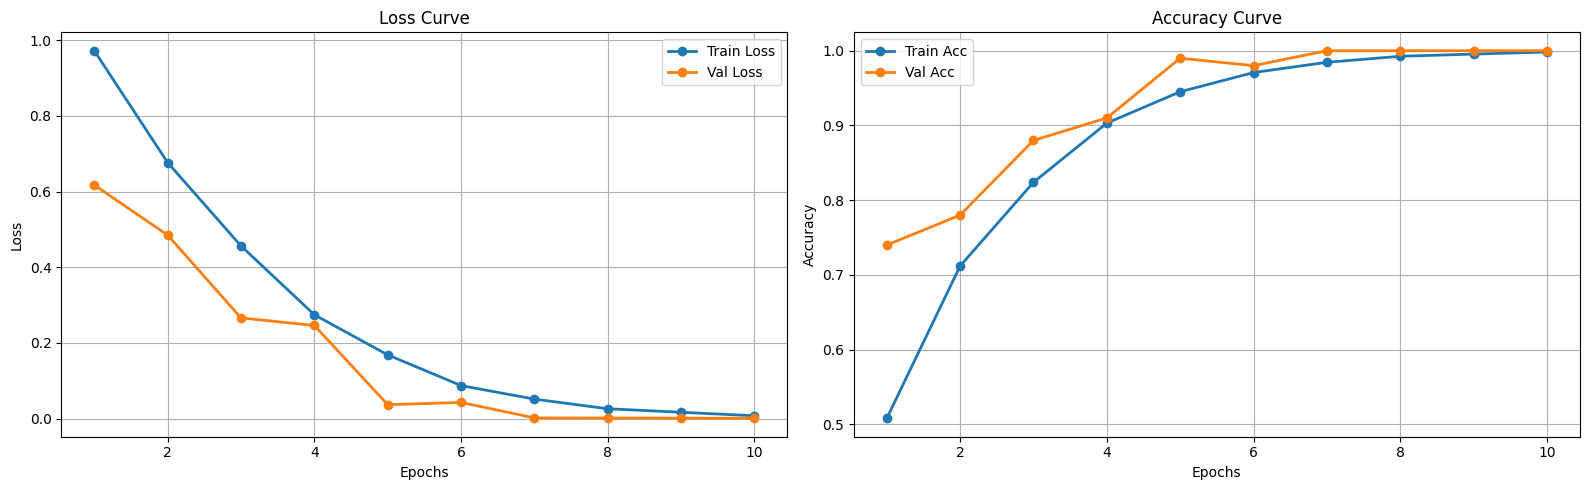

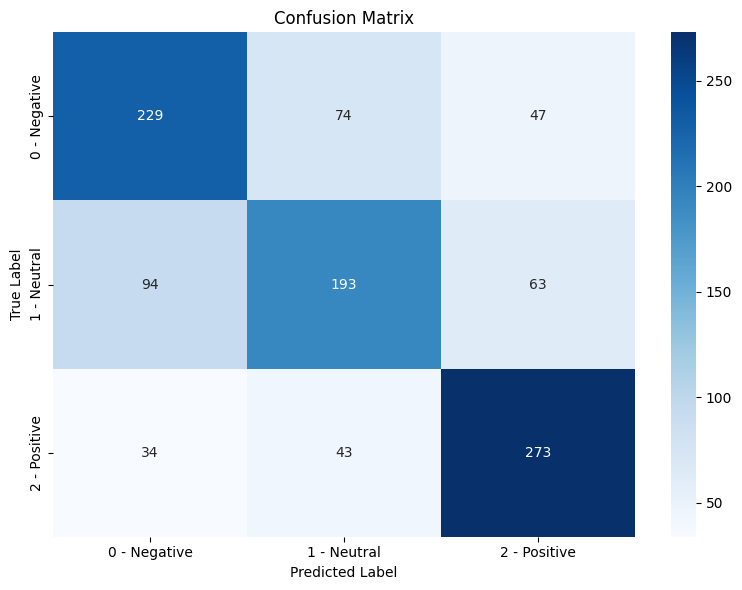

In [3]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from torch.optim import AdamW
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ==========================================
# 1. HÀM ĐỌC DỮ LIỆU TỪ FILE TXT
# ==========================================
label_to_idx = {
    "NEG": 0,
    "NEU": 1,
    "POS": 2
}

def load_sentiment_data(csv_path):
    df = pd.read_csv(csv_path)

    # bỏ dòng lỗi nếu có
    df = df.dropna(subset=["texts", "labels"])

    texts = df["texts"].astype(str).tolist()

    labels = [
        label_to_idx[label]
        for label in df["labels"]
    ]

    return texts, labels

# Giả sử cấu trúc thư mục của bạn nằm ở cùng cấp với script này
DATA_PATH = "/kaggle/input/datasets/easterharry/vlsp-2016"

train_texts, train_labels = load_sentiment_data(
    os.path.join(DATA_PATH, "train.csv")
)

val_texts, val_labels = load_sentiment_data(
    os.path.join(DATA_PATH, "dev.csv")
)

test_texts, test_labels = load_sentiment_data(
    os.path.join(DATA_PATH, "test.csv")
)
# ==========================================
# 2. XÂY DỰNG PYTORCH DATASET
# ==========================================
class UIT_VSFC_Dataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenizer sẽ tự động padding/truncation về max_len
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# ==========================================
# 3. KHỞI TẠO TOKENIZER & MODEL
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng device: {device}")

# Sử dụng model ViSoBERT (hoặc có thể thay bằng 'vinai/phobert-base' tuỳ nhu cầu)
model_name = "uitnlp/visobert" 
num_labels = 3 # Nhãn: 0 (Negative), 1 (Neutral), 2 (Positive)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
model.to(device)

# ==========================================
# 4. TẠO DATALOADER
# ==========================================
train_dataset = UIT_VSFC_Dataset(train_texts, train_labels, tokenizer)
val_dataset = UIT_VSFC_Dataset(val_texts, val_labels, tokenizer)
test_dataset = UIT_VSFC_Dataset(test_texts, test_labels, tokenizer)

# Batch size có thể chỉnh về 16 hoặc 32 tuỳ thuộc dung lượng VRAM
train_loader = DataLoader(train_dataset, batch_size=40, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=40, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=40, shuffle=False)

# ==========================================
# 5. THIẾT LẬP THAM SỐ HUẤN LUYỆN
# ==========================================
epochs = 10
optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_loader) * epochs
warm=int(0.1 * total_steps)
scheduler = get_scheduler(
    "linear", optimizer=optimizer, num_warmup_steps=warm, num_training_steps=total_steps
)

# ==========================================
# 6. VÒNG LẶP HUẤN LUYỆN (TRAINING LOOP)
# ==========================================
best_model = None
# Định dạng thanh tiến trình đẹp (Giống Hugging Face)
bar_format = '{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}{postfix}]'

train_losses, train_accs = [], []
val_losses, val_accuracies = [], []
best_val_loss = float('inf')

for epoch in range(epochs):
    print(f'\n{"="*20} Epoch {epoch + 1}/{epochs} {"="*20}')
    
    # --- 6.1 Training ---
    model.train()
    total_train_loss = 0
    train_preds, train_true = [], []
    
    # Thêm 'postfix' để hiển thị Loss/Acc ngay trên thanh tiến trình
    train_loop = tqdm(train_loader, desc="Training", bar_format=bar_format)
    for batch in train_loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        # Cập nhật thông số lên thanh tiến trình
        total_train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=-1)
        train_preds.extend(preds.cpu().numpy())
        train_true.extend(labels.cpu().numpy())
        
        train_loop.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc = accuracy_score(train_true, train_preds)
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)
    
    # --- 6.2 Validation ---
    model.eval()
    total_val_loss = 0
    val_preds, val_true = [], []
    
    val_loop = tqdm(val_loader, desc="Validation", bar_format=bar_format)
    with torch.no_grad():
        for batch in val_loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()
            
            preds = torch.argmax(outputs.logits, dim=-1)
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_acc = accuracy_score(val_true, val_preds)
    
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    
    # In kết quả sau mỗi epoch một cách sạch sẽ
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Lưu best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(">>> Saved best model!")

# ==========================================
# 7. LƯU MÔ HÌNH THÀNH FILE .PTH
# ==========================================
print(f"\n✅ Đã lưu trọng số mô hình thành công")

# ==========================================
# 8. ĐÁNH GIÁ TRÊN TẬP TEST
# ==========================================
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
test_preds, test_true = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Kiểm thử (Testing)"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)

        test_preds.extend(preds.cpu().numpy())
        test_true.extend(labels.cpu().numpy())

print("\n--- Báo cáo kết quả phân loại (Test Classification Report) ---")
target_names = ['0 - Negative', '1 - Neutral', '2 - Positive']
print(classification_report(test_true, test_preds, target_names=target_names))

# ==========================================
# 9. VẼ BIỂU ĐỒ TRAINING & VALIDATION (LOSS & ACC)
# ==========================================
def plot_all_metrics(train_losses, train_accs, val_losses, val_accs):
    epochs = range(1, len(train_losses) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Biểu đồ Loss
    ax1.plot(epochs, train_losses, marker='o', linewidth=2, label='Train Loss')
    ax1.plot(epochs, val_losses, marker='o', linewidth=2, label='Val Loss')
    ax1.set_title('Loss Curve')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Biểu đồ Accuracy
    ax2.plot(epochs, train_accs, marker='o', linewidth=2, label='Train Acc')
    ax2.plot(epochs, val_accs, marker='o', linewidth=2, label='Val Acc')
    ax2.set_title('Accuracy Curve')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

plot_all_metrics(train_losses, train_accs, val_losses, val_accuracies)
plot_confusion_matrix(test_true, test_preds, target_names)

In [4]:
print("\n--- Báo cáo kết quả phân loại (Test Classification Report) ---")
target_names = ['0 - Negative', '1 - Neutral', '2 - Positive']
print(classification_report(test_true, test_preds, target_names=target_names,digits=4))


--- Báo cáo kết quả phân loại (Test Classification Report) ---
              precision    recall  f1-score   support

0 - Negative     0.6415    0.6543    0.6478       350
 1 - Neutral     0.6226    0.5514    0.5848       350
2 - Positive     0.7128    0.7800    0.7449       350

    accuracy                         0.6619      1050
   macro avg     0.6589    0.6619    0.6592      1050
weighted avg     0.6589    0.6619    0.6592      1050

